In [798]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import seaborn as sns

df = pd.read_csv('/content/Model_Training_Data.csv')
df['Pstng Date'] = pd.to_datetime(df['Pstng Date'])
df

,Name,Pstng Date,Weekly_Period,transaction_count,transaction_flow_mean,transaction_flow_total
0,ID10,2025-01-02,2025-01-W1,36,-87.719876,-3157.91553
1,ID10,2025-01-03,2025-01-W1,15,-41.142732,-617.14098
2,ID10,2025-01-04,2025-01-W1,44,-757.633248,-33335.86291
3,ID10,2025-01-05,2025-01-W1,2,-7.309050,-14.61810
4,ID10,2025-01-06,2025-01-W2,39,-526.328670,-20526.81812
...,...,...,...,...,...,...
1616,VN20,2025-10-25,2025-10-W4,127,-6428.658024,-816439.56905
1617,VN20,2025-10-26,2025-10-W4,116,-60.959892,-7071.34743
1618,VN20,2025-10-27,2025-11-W1,198,-88.057576,-17435.40005
1619,VN20,2025-10-30,2025-11-W1,7,1646.607907,11526.25535


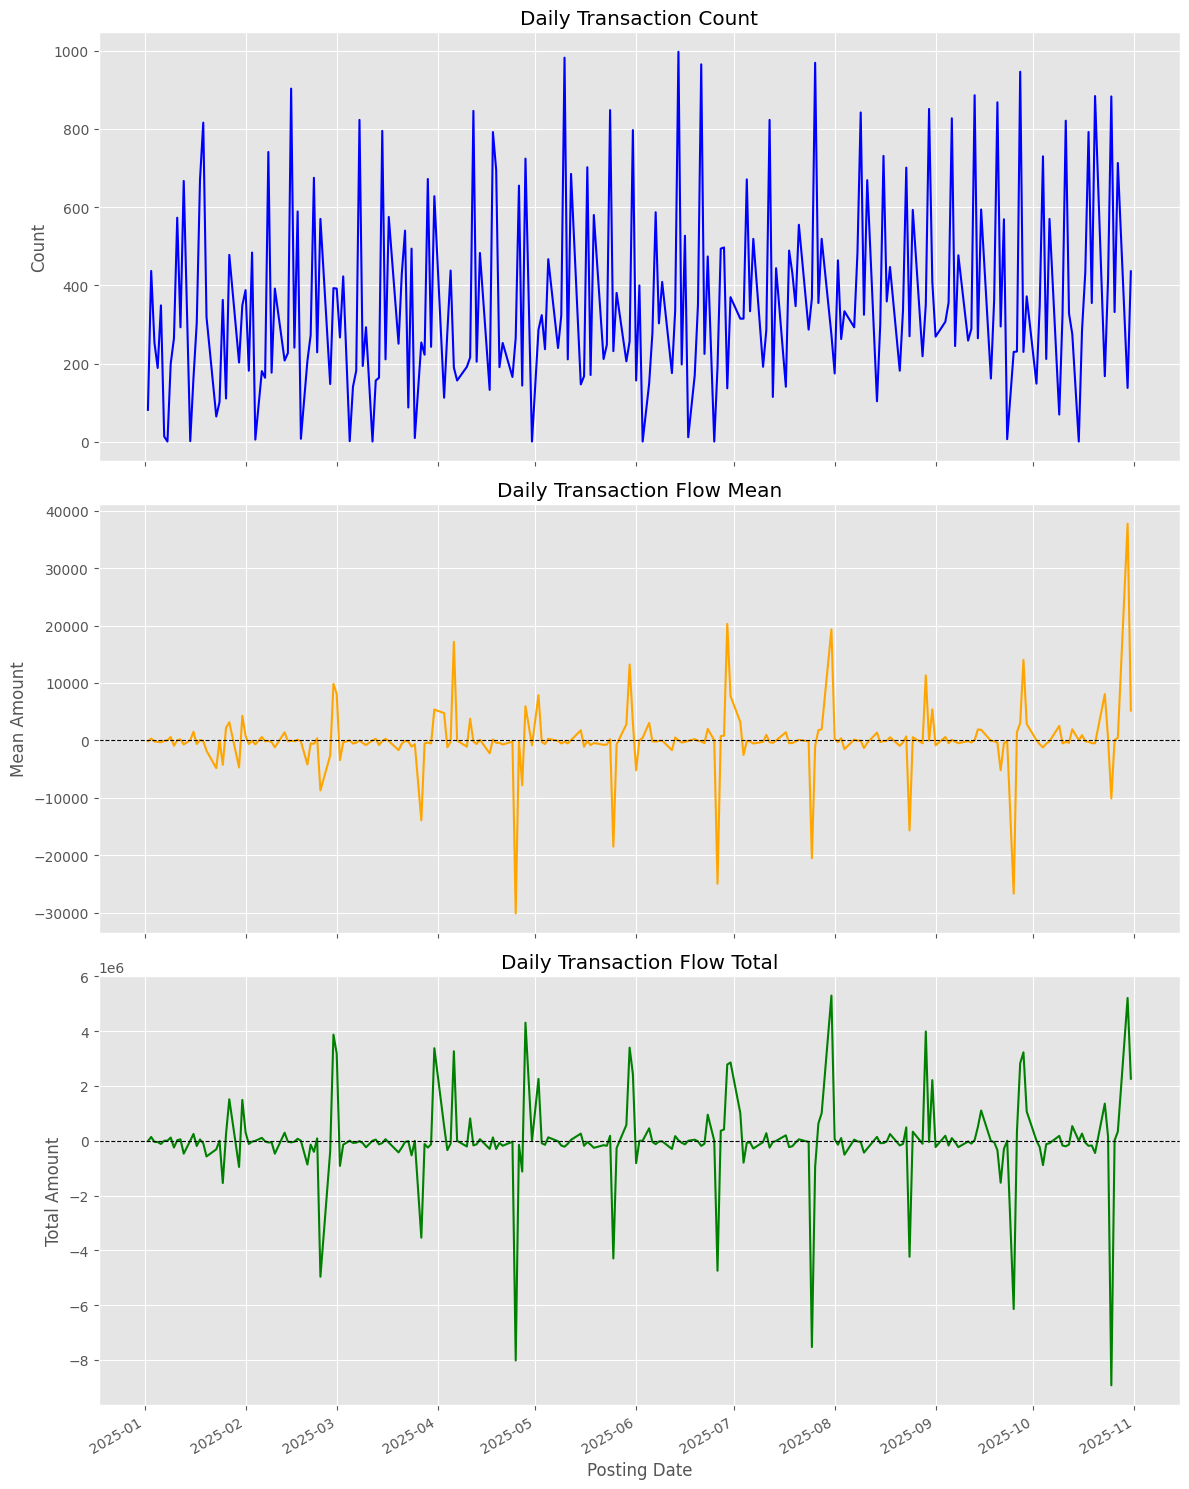

In [799]:
df['Pstng Date'] = pd.to_datetime(df['Pstng Date'])

daily_agg = df.groupby('Pstng Date').agg({
    'transaction_count': 'sum',
    'transaction_flow_total': 'sum'
}).reset_index()

daily_agg['daily_mean'] = daily_agg['transaction_flow_total'] / daily_agg['transaction_count']

plt.style.use('ggplot')
fig, axes = plt.subplots(3, 1, figsize=(12, 15), sharex=True)

axes[0].plot(daily_agg['Pstng Date'], daily_agg['transaction_count'], color='blue', linewidth=1.5)
axes[0].set_title('Daily Transaction Count')
axes[0].set_ylabel('Count')
axes[0].grid(True)

axes[1].plot(daily_agg['Pstng Date'], daily_agg['daily_mean'], color='orange', linewidth=1.5)
axes[1].set_title('Daily Transaction Flow Mean')
axes[1].set_ylabel('Mean Amount')
axes[1].grid(True)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')

axes[2].plot(daily_agg['Pstng Date'], daily_agg['transaction_flow_total'], color='green', linewidth=1.5)
axes[2].set_title('Daily Transaction Flow Total')
axes[2].set_ylabel('Total Amount')
axes[2].set_xlabel('Posting Date')
axes[2].grid(True)
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')

axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[2].xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

In [800]:
daily_net_flow = df.groupby('Pstng Date')['transaction_flow_total'].sum().reset_index()
daily_net_flow['delta_cashflow'] = daily_net_flow['transaction_flow_total'].diff()
daily_net_flow.head()

,Pstng Date,transaction_flow_total,delta_cashflow
0,2025-01-02,-13605.12368,NaN
1,2025-01-03,137048.38835,150653.51203
2,2025-01-04,-43476.03483,-180524.42318
3,2025-01-05,-48472.96811,-4996.93328
4,2025-01-06,-117887.39105,-69414.42294


In [801]:
delta_cashflow_mean = daily_net_flow['delta_cashflow'].mean()
delta_cashflow_std = daily_net_flow['delta_cashflow'].std()

big_rise_threshold = delta_cashflow_mean + (2 * delta_cashflow_std)
big_drop_threshold = delta_cashflow_mean - (2 * delta_cashflow_std)

daily_net_flow['is_big_rise'] = daily_net_flow['delta_cashflow'] > big_rise_threshold
daily_net_flow['is_big_drop'] = daily_net_flow['delta_cashflow'] < big_drop_threshold

print(f"Mean of daily cashflow change: ${delta_cashflow_mean:,.2f}")
print(f"Standard deviation of daily cashflow change: ${delta_cashflow_std:,.2f}")
print(f"Big rise threshold: ${big_rise_threshold:,.2f}")
print(f"Big drop threshold: ${big_drop_threshold:,.2f}")

Mean of daily cashflow change: $9,941.11
Standard deviation of daily cashflow change: $2,117,572.08
Big rise threshold: $4,245,085.27
Big drop threshold: $-4,225,203.06


In [802]:
significant_event_dates = daily_net_flow[
    daily_net_flow['is_big_rise'] | daily_net_flow['is_big_drop']
]['Pstng Date'].tolist()

df_significant_events = df[df['Pstng Date'].isin(significant_event_dates)].copy()

print(f"Number of significant event dates identified: {len(significant_event_dates)}")
print(f"Number of transactions on significant event dates: {len(df_significant_events)}")
print("First 5 transactions on significant event dates:")
print(df_significant_events.head())

Number of significant event dates identified: 21
Number of transactions on significant event dates: 155
First 5 transactions on significant event dates:
    Name Pstng Date Weekly_Period  transaction_count  transaction_flow_mean  \
38  ID10 2025-02-24    2025-03-W1                 67           -5305.518542   
39  ID10 2025-02-27    2025-03-W1                 18            1659.277027   
40  ID10 2025-02-28    2025-03-W1                 77            -128.343069   
73  ID10 2025-04-26    2025-04-W4                159           -1780.910729   
75  ID10 2025-04-28    2025-05-W1                115            2085.073485   

    transaction_flow_total  
38           -355469.74231  
39             29866.98649  
40             -9882.41631  
73           -283164.80586  
75            239783.45075  


In [803]:
daily_net_flow['delta_cashflow_lag1'] = daily_net_flow['delta_cashflow'].shift(1)

lagged_correlation = daily_net_flow['delta_cashflow'].corr(daily_net_flow['delta_cashflow_lag1'])

print(f"Lagged correlation (delta_cashflow vs delta_cashflow_lag1): {lagged_correlation:.4f}")

Lagged correlation (delta_cashflow vs delta_cashflow_lag1): -0.4261


In [804]:
for k in range(1,6):
    print(k, daily_net_flow['delta_cashflow'].corr(
        daily_net_flow['delta_cashflow'].shift(k)
    ))

1 -0.4261311612831456
2 0.050365206258102965
3 -0.1988546170109085
4 0.04582893315573702
5 -0.000818496955501001


--- Typical Cash Flow by Day of Month (Median) ---
day_of_month
1     8613.107853
2    -6802.561840
3      454.417620
4   -43368.502258
5    -7526.207774
Name: transaction_flow_total, dtype: float64


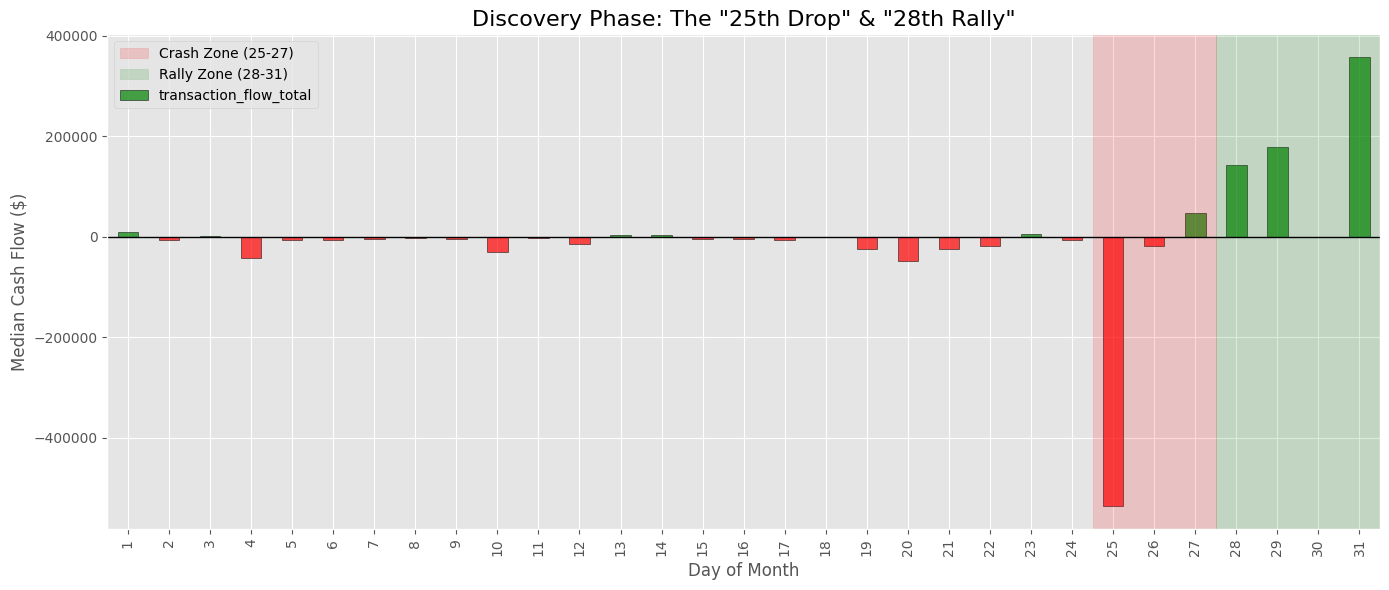

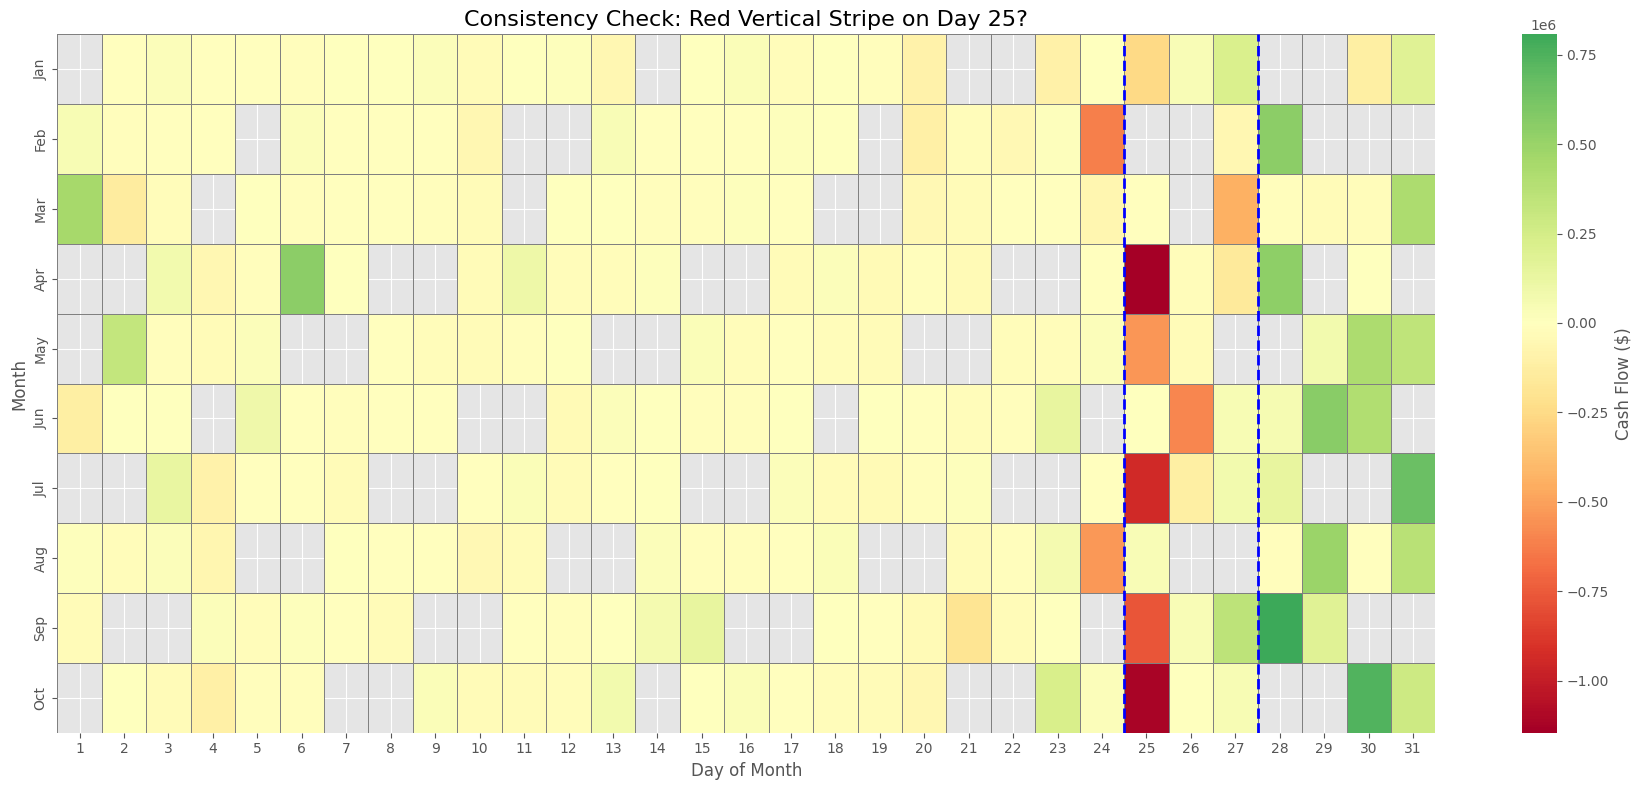

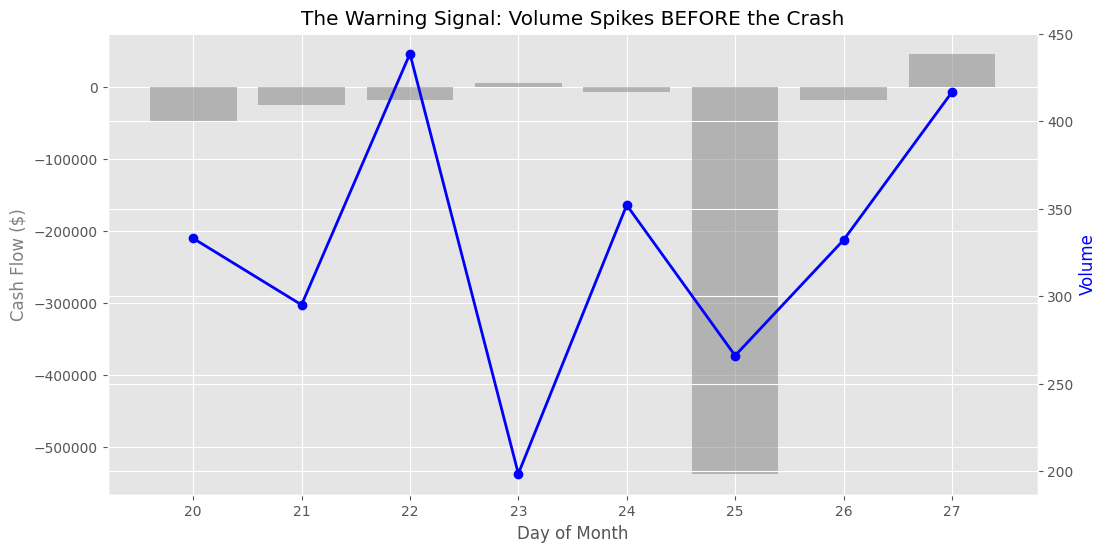

--- Daily Seasonality Profile ---
day_of_month
1       8613.107853
2      -6802.561840
3        454.417620
4     -43368.502258
5      -7526.207774
6      -6852.589007
7      -4990.430313
8      -2969.768671
9      -5510.066844
10    -30009.377434
11     -3574.593278
12    -15260.386737
13      4125.518845
14      2370.947742
15     -3673.495965
16     -4407.919015
17     -5878.973231
18     -1352.373390
19    -24833.191626
20    -48102.782512
21    -24610.091470
22    -17908.019128
23      5116.435167
24     -6334.869729
25   -536991.752859
26    -18547.000106
27     46370.757480
28    143270.293567
29    178264.835177
30      -833.352220
31    357994.077978
Name: transaction_flow_total, dtype: float64


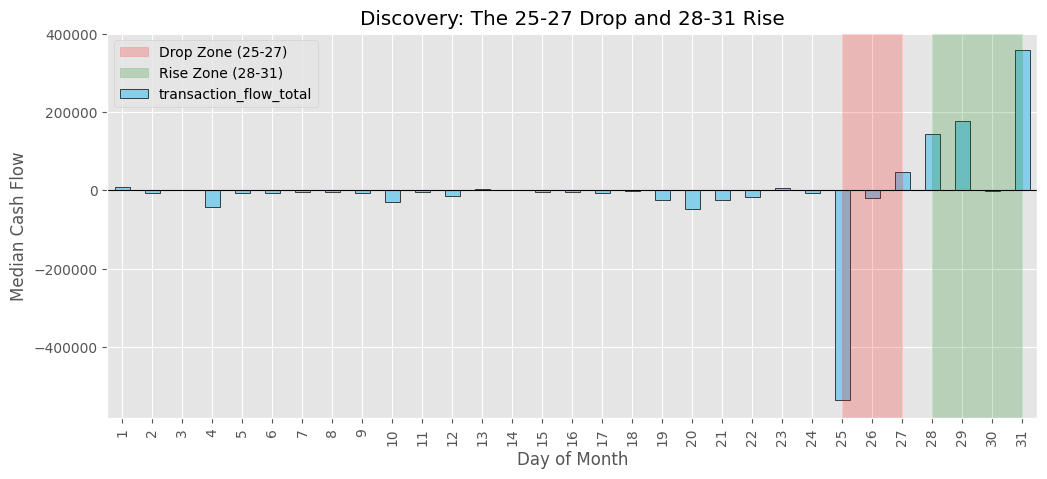

In [805]:
daily_data = df.groupby('Pstng Date').agg({
    'transaction_flow_total': 'mean',
    'transaction_count': 'sum'
}).reset_index()

# Extract Date Features
daily_data['day_of_month'] = daily_data['Pstng Date'].dt.day
daily_data['month'] = daily_data['Pstng Date'].dt.month
daily_data['month_name'] = daily_data['Pstng Date'].dt.strftime('%b')

# --- 2. The "Habit" Discovery (Bar Chart) ---
seasonality_profile = daily_data.groupby('day_of_month')['transaction_flow_total'].median()

print("--- Typical Cash Flow by Day of Month (Median) ---")
print(seasonality_profile.head())

# Plot 1: Bar Chart
plt.figure(figsize=(14, 6))
colors = ['red' if x < 0 else 'green' for x in seasonality_profile.values]
seasonality_profile.plot(kind='bar', color=colors, edgecolor='black', alpha=0.7)
plt.title('Discovery Phase: The "25th Drop" & "28th Rally"', fontsize=16)
plt.xlabel('Day of Month')
plt.ylabel('Median Cash Flow ($)')
plt.axhline(0, color='black', linewidth=1)
# Highlight Zones
plt.axvspan(23.5, 26.5, color='red', alpha=0.15, label='Crash Zone (25-27)')
plt.axvspan(26.5, 30.5, color='green', alpha=0.15, label='Rally Zone (28-31)')
plt.legend()
plt.tight_layout()
plt.show()

# --- 3. The "Consistency" Check (Heatmap) ---
# FIX: Explicitly aggregate ONLY the 'transaction_flow_total' column
heatmap_data = daily_data.pivot_table(
    index='month_name',
    columns='day_of_month',
    values='transaction_flow_total',  # <--- This line ensures we only calc median on numbers
    aggfunc='median'
)

# Reorder months
months_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
# Filter strictly to months that exist in your data to avoid errors
existing_months = [m for m in months_order if m in heatmap_data.index]
heatmap_data = heatmap_data.reindex(existing_months)

# Plot 2: Heatmap
plt.figure(figsize=(18, 8))
sns.heatmap(heatmap_data, cmap='RdYlGn', center=0, linewidths=.5, linecolor='gray', cbar_kws={'label': 'Cash Flow ($)'})
plt.title('Consistency Check: Red Vertical Stripe on Day 25?', fontsize=16)
plt.xlabel('Day of Month')
plt.ylabel('Month')
# Highlight Day 25
plt.axvline(24, color='blue', linestyle='--', linewidth=2)
plt.axvline(27, color='blue', linestyle='--', linewidth=2)
plt.tight_layout()
plt.show()

# --- 4. The Signal Search (Volume) ---
# Filter for days leading up to the crash
check_days = daily_data[daily_data['day_of_month'].between(20, 27)].copy()
typical_check = check_days.groupby('day_of_month')[['transaction_flow_total', 'transaction_count']].median()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

ax1.bar(typical_check.index, typical_check['transaction_flow_total'], color='gray', alpha=0.5, label='Cash Flow')
ax2.plot(typical_check.index, typical_check['transaction_count'], color='blue', marker='o', linewidth=2, label='Volume')

ax1.set_ylabel('Cash Flow ($)', color='gray')
ax2.set_ylabel('Volume', color='blue')
ax1.set_xlabel('Day of Month')
plt.title('The Warning Signal: Volume Spikes BEFORE the Crash')
plt.show()

daily_data = df.groupby('Pstng Date')['transaction_flow_total'].mean().reset_index()

daily_data['day_of_month'] = daily_data['Pstng Date'].dt.day

seasonality_profile = daily_data.groupby('day_of_month')['transaction_flow_total'].median()

# Print the profile to see the numbers
print("--- Daily Seasonality Profile ---")
print(seasonality_profile)

# Visualize to confirm the pattern
plt.figure(figsize=(12, 5))
seasonality_profile.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Discovery: The 25-27 Drop and 28-31 Rise')
plt.xlabel('Day of Month')
plt.ylabel('Median Cash Flow')
plt.axhline(0, color='black', linewidth=0.8)
plt.axvspan(24, 26, color='red', alpha=0.2, label='Drop Zone (25-27)') # 0-indexed: 24=25th
plt.axvspan(27, 30, color='green', alpha=0.2, label='Rise Zone (28-31)')
plt.legend()
plt.show()

In [806]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

df = pd.read_csv('/content/Model_Training_Data.csv')

In [807]:
df['Pstng Date'] = pd.to_datetime(df['Pstng Date'])

daily_data = df.groupby('Pstng Date').agg({
    'transaction_flow_total': 'mean',
    'transaction_count': 'sum'
}).reset_index()

daily_data['day_of_month'] = daily_data['Pstng Date'].dt.day
daily_data['day_of_week'] = daily_data['Pstng Date'].dt.dayofweek

In [808]:
#Feature Engineering

# 1. Volume Lag 4
daily_data['volume_lag4'] = daily_data['transaction_count'].shift(2)

# 2. Market Context (Volatility)
daily_data['volatility_7d'] = daily_data['transaction_flow_total'].rolling(3).std().shift(1)

# 3. Calendar Flags
daily_data['is_friday'] = (daily_data['day_of_week'] == 4).astype(int)
daily_data['is_month_end'] = daily_data['Pstng Date'].dt.is_month_end.astype(int)

model_data = daily_data.dropna().reset_index(drop=True)

In [809]:
models_dict = {
    "Linear Regression": LinearRegression(),
    "Ridge (L2)": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
}

In [810]:
#('2025-10-01', "1 Month Test")
#('2025-05-01', "6 Months Test")
split_date = '2025-05-01'
experiment_name = "6 Months Test"
print(f"\n{experiment_name} (Split: {split_date})")

train = model_data[model_data['Pstng Date'] < split_date].copy()
test = model_data[model_data['Pstng Date'] >= split_date].copy()

SENSITIVITY_FACTOR = 0.40

p_median = train.groupby('day_of_month')['transaction_flow_total'].median()
p_crash  = train.groupby('day_of_month')['transaction_flow_total'].quantile(0.10)
p_rally  = train.groupby('day_of_month')['transaction_flow_total'].quantile(0.90)
aggressive_profile = p_median.copy()

crash_days = aggressive_profile.index.intersection([25, 26, 27])
rally_days = aggressive_profile.index.intersection([28, 29, 30, 31])

aggressive_profile.loc[crash_days] = p_crash.loc[crash_days] * SENSITIVITY_FACTOR
aggressive_profile.loc[rally_days] = p_rally.loc[rally_days] * SENSITIVITY_FACTOR


6 Months Test (Split: 2025-05-01)


In [811]:
train['aggressive_base'] = train['day_of_month'].map(aggressive_profile)
test['aggressive_base'] = test['day_of_month'].map(aggressive_profile)

if test['aggressive_base'].isnull().any():
    test['aggressive_base'].fillna(aggressive_profile.median(), inplace=True)

train['residual'] = train['transaction_flow_total'] - train['aggressive_base']

In [812]:
features = ['volume_lag4', 'volatility_7d', 'is_friday', 'is_month_end'] #
results_list = []
predictions = {}
for name, model in models_dict.items():
    model.fit(train[features], train['residual'])

    test_pred_residual = model.predict(test[features])
    final_pred = test['aggressive_base'] + test_pred_residual
    predictions[name] = final_pred

    r2 = r2_score(test['transaction_flow_total'], final_pred)
    mae = mean_absolute_error(test['transaction_flow_total'], final_pred)
    rmse = np.sqrt(mean_squared_error(test['transaction_flow_total'], final_pred))

    results_list.append({
        'Model': name,
        'R2': r2,
        'MAE': mae,
        'RMSE': rmse
    })

               Model        R2            MAE           RMSE
1         Ridge (L2)  0.319758  106917.356526  188134.117738
0  Linear Regression  0.315848  107560.408167  188674.117374
2      Random Forest  0.261872  120048.550972  195975.482892
3  Gradient Boosting  0.203230  126421.281523  203611.629382


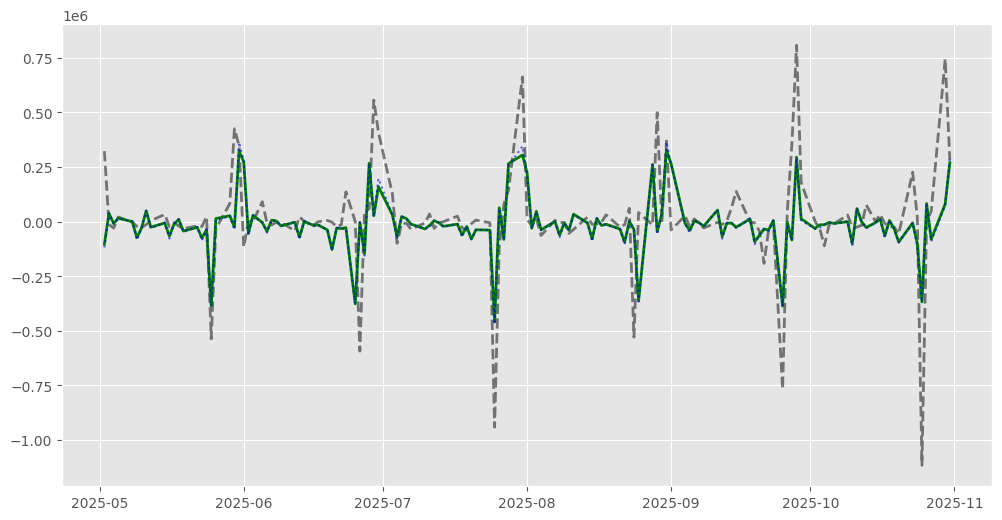

In [813]:
results_df = pd.DataFrame(results_list).sort_values('R2', ascending=False)
print(results_df)

best_model_name = results_df.iloc[0]['Model']
best_preds = predictions[best_model_name]
plt.figure(figsize=(12, 6))
plt.plot(test['Pstng Date'], test['transaction_flow_total'], label='Actual', color='black', alpha=0.5, linewidth=2, linestyle='--')
plt.plot(test['Pstng Date'], best_preds, label=f'Best Model: {best_model_name} (R2={results_df.iloc[0]["R2"]:.2f})', color='green', linewidth=2)
if best_model_name != "Linear Regression":
    plt.plot(test['Pstng Date'], predictions["Linear Regression"], label='Linear Baseline', color='blue', alpha=0.6, linestyle=':')

In [814]:
#Feature Engineering

# 1. Volume Lag 4
daily_data['volume_lag4'] = daily_data['transaction_count'].shift(4)

# 2. Market Context (Volatility)
daily_data['volatility_7d'] = daily_data['transaction_flow_total'].rolling(7).std().shift(1)

# 3. Calendar Flags
daily_data['is_friday'] = (daily_data['day_of_week'] == 4).astype(int)
daily_data['is_month_end'] = daily_data['Pstng Date'].dt.is_month_end.astype(int)

model_data = daily_data.dropna().reset_index(drop=True)

In [815]:
split_date = '2025-10-01'
experiment_name = "1 Months Test"
print(f"\n{experiment_name} (Split: {split_date})")

train = model_data[model_data['Pstng Date'] < split_date].copy()
test = model_data[model_data['Pstng Date'] >= split_date].copy()

SENSITIVITY_FACTOR = 1.2

p_median = train.groupby('day_of_month')['transaction_flow_total'].median()
p_crash  = train.groupby('day_of_month')['transaction_flow_total'].quantile(0.10)
p_rally  = train.groupby('day_of_month')['transaction_flow_total'].quantile(0.90)
aggressive_profile = p_median.copy()

crash_days = aggressive_profile.index.intersection([25, 26, 27])
rally_days = aggressive_profile.index.intersection([28, 29, 30, 31])

aggressive_profile.loc[crash_days] = p_crash.loc[crash_days] * SENSITIVITY_FACTOR
aggressive_profile.loc[rally_days] = p_rally.loc[rally_days] * SENSITIVITY_FACTOR


1 Months Test (Split: 2025-10-01)


In [816]:
train['aggressive_base'] = train['day_of_month'].map(aggressive_profile)
test['aggressive_base'] = test['day_of_month'].map(aggressive_profile)

if test['aggressive_base'].isnull().any():
    test['aggressive_base'].fillna(aggressive_profile.median(), inplace=True)

train['residual'] = train['transaction_flow_total'] - train['aggressive_base']

In [817]:
features = ['volume_lag4', 'volatility_7d','is_friday', 'is_month_end']
results_list = []
predictions = {}
for name, model in models_dict.items():
    model.fit(train[features], train['residual'])

    test_pred_residual = model.predict(test[features])
    final_pred = test['aggressive_base'] + test_pred_residual
    predictions[name] = final_pred

    r2 = r2_score(test['transaction_flow_total'], final_pred)
    mae = mean_absolute_error(test['transaction_flow_total'], final_pred)
    rmse = np.sqrt(mean_squared_error(test['transaction_flow_total'], final_pred))

    results_list.append({
        'Model': name,
        'R2': r2,
        'MAE': mae,
        'RMSE': rmse
    })

               Model        R2           MAE           RMSE
3  Gradient Boosting  0.876914  79344.965047  102401.404580
2      Random Forest  0.820885  75249.647343  123528.642773
0  Linear Regression  0.793001  84861.312327  132796.108079
1         Ridge (L2)  0.784191  86309.872849  135592.467816


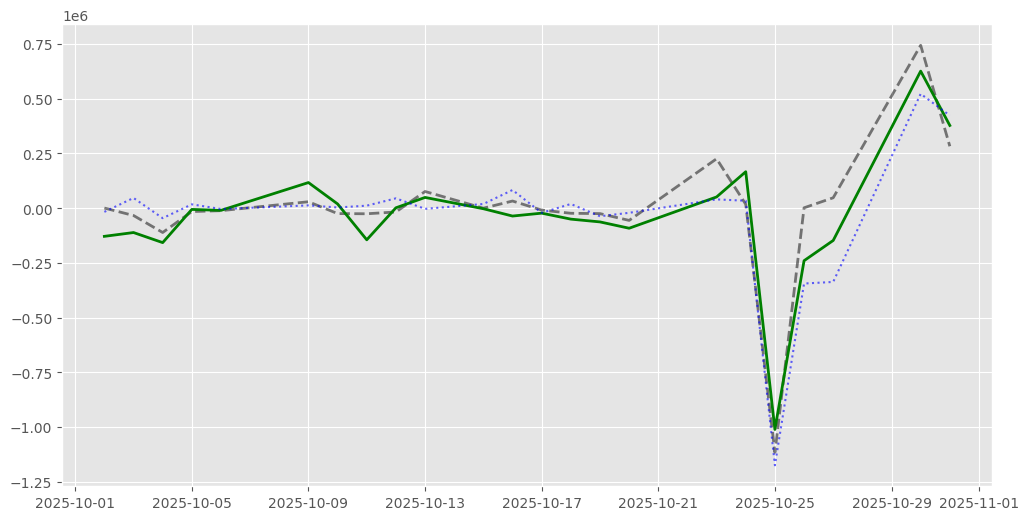

In [818]:
results_df = pd.DataFrame(results_list).sort_values('R2', ascending=False)
print(results_df)

best_model_name = results_df.iloc[0]['Model']
best_preds = predictions[best_model_name]
plt.figure(figsize=(12, 6))
plt.plot(test['Pstng Date'], test['transaction_flow_total'], label='Actual', color='black', alpha=0.5, linewidth=2, linestyle='--')
plt.plot(test['Pstng Date'], best_preds, label=f'Best Model: {best_model_name} (R2={results_df.iloc[0]["R2"]:.2f})', color='green', linewidth=2)
if best_model_name != "Linear Regression":
    plt.plot(test['Pstng Date'], predictions["Linear Regression"], label='Linear Baseline', color='blue', alpha=0.6, linestyle=':')